# LDA Evaluation - Task 2.2 (Member 3)
## Đánh giá LDA với data preprocessed

**Data:** `data/preprocessed/result.csv` (150 documents)  
**Mục tiêu:** Tính Topic Coherence Score cho k = 15, 18, 20, 22, 25

In [1]:
# ============================================================================
# CELL 1: IMPORTS & CẤU HÌNH
# ============================================================================

import os
import re
import warnings
import logging

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib

# Gensim for topic modeling
from gensim.corpora import Dictionary
from gensim.models import LdaMulticore, CoherenceModel

# Cấu hình
matplotlib.rcParams['font.size'] = 12
matplotlib.rcParams['figure.figsize'] = (14, 6)
warnings.filterwarnings('ignore', category=DeprecationWarning)
logging.basicConfig(format='%(asctime)s : %(levelname)s : %(message)s', level=logging.INFO)

print('✅ Imports OK')

✅ Imports OK


In [2]:
# ============================================================================
# CELL 2: LOAD DỮ LIỆU PREPROCESSED
# ============================================================================

DATA_PATH = '../data/preprocessed/result.csv'
STOPWORDS_PATH = '../data/stopwords_vi.txt'

# Load data
df = pd.read_csv(DATA_PATH)
print(f"📊 Loaded {len(df)} documents")
print(f"📝 Columns: {df.columns.tolist()}")
print(f"\nFirst 3 rows:")
df[['post_id', 'clean_text', 'sentiment_label']].head(3)

📊 Loaded 150 documents
📝 Columns: ['post_id', 'source', 'content', 'clean_text', 'sentiment_label', 'sentiment_id', 'confidence', 'post_type', 'author', 'author_id', 'created_at', 'reaction_count', 'view_count', 'comment_count', 'parent_post_id', 'title', 'tags']

First 3 rows:


,post_id,clean_text,sentiment_label
0,4b4f34927c6c,bài đánh_giá tâm quá thanks_thím chia_sẻ anh_e...,Positive
1,07e24004a61a,cấu_hình ngon đấy người tạo bài cứ thế mà làm ...,Positive
2,29faea92f72c,mình nghĩ nên đợi thêm một thời_gian để xem cá...,Negative


In [3]:
# ============================================================================
# CELL 3: LOAD STOPWORDS
# ============================================================================

with open(STOPWORDS_PATH, 'r', encoding='utf-8') as f:
    STOPWORDS = set(line.strip() for line in f if line.strip())

print(f"✅ Loaded {len(STOPWORDS)} stopwords")
print(f"📝 Sample stopwords: {list(STOPWORDS)[:10]}")

✅ Loaded 1942 stopwords
📝 Sample stopwords: ['theo bước', 'phỏng như', 'bạn', 'cũng như', 'khi nên', 'phần việc', 'phải khi', 'số thiếu', 'ờ', 'lấy làm']


In [4]:
# ============================================================================
# CELL 4: TOKENIZE CLEAN_TEXT
# ============================================================================

def tokenize_clean_text(text):
    """
    Tokenize text đã preprocessed.
    clean_text đã qua word segmentation (có dấu _), chỉ cần:
    1. Split bằng space
    2. Lọc stopwords
    3. Lọc từ quá ngắn và số
    """
    if pd.isna(text):
        return []
    
    text = str(text).lower().strip()
    tokens = text.split()
    
    # Lọc stopwords, từ ngắn, số
    tokens = [
        w for w in tokens 
        if w not in STOPWORDS 
        and len(w) > 1
        and not w.isdigit()
    ]
    
    return tokens

# Áp dụng tokenization
print("🔄 Tokenizing clean_text...")
df['tokens'] = df['clean_text'].apply(tokenize_clean_text)

# Lọc documents có ít nhất 5 tokens
df = df[df['tokens'].apply(len) >= 5]
documents = df['tokens'].tolist()

print(f"✅ Tokenized {len(documents)} documents")
print(f"📝 Sample tokens from doc 1: {documents[0][:15] if len(documents) > 0 else 'N/A'}")
print(f"📝 Sample tokens from doc 2: {documents[1][:15] if len(documents) > 1 else 'N/A'}")

🔄 Tokenizing clean_text...
✅ Tokenized 129 documents
📝 Sample tokens from doc 1: ['đánh_giá', 'tâm', 'thanks_thím', 'chia_sẻ', 'anh_em', 'mở_mang', 'tầm_mắt']
📝 Sample tokens from doc 2: ['đợi', 'thời_gian', 'thử_thách', 'tình_cảm', 'nhiệt_độ', 'độc_lập', 'hẵng', 'quyết_định', 'cuối_cùng']


In [5]:
# ============================================================================
# CELL 5: TẠO DICTIONARY & CORPUS
# ============================================================================

# Tạo Gensim Dictionary
print("📚 Creating Gensim Dictionary...")
dictionary = Dictionary(documents)
print(f"   Initial vocabulary: {len(dictionary)} unique tokens")

# Filter extremes
dictionary.filter_extremes(
    no_below=3,      # Từ phải xuất hiện ít nhất 3 documents
    no_above=0.7,    # Từ không xuất hiện quá 70% documents
    keep_n=5000      # Giữ tối đa 5K từ (với 150 docs)
)

print(f"✅ Filtered vocabulary: {len(dictionary)} unique tokens")

# Tạo Bag-of-Words corpus
corpus = [dictionary.doc2bow(doc) for doc in documents]
print(f"✅ Created corpus: {len(corpus)} documents")
print(f"📝 Sample BOW (doc 1): {corpus[0][:10]}")

2026-04-04 10:26:04,018 : INFO : adding document #0 to Dictionary<0 unique tokens: []>
2026-04-04 10:26:04,018 : INFO : built Dictionary<119 unique tokens: ['anh_em', 'chia_sẻ', 'mở_mang', 'thanks_thím', 'tâm']...> from 129 documents (total 1034 corpus positions)
2026-04-04 10:26:04,018 : INFO : Dictionary lifecycle event {'msg': "built Dictionary<119 unique tokens: ['anh_em', 'chia_sẻ', 'mở_mang', 'thanks_thím', 'tâm']...> from 129 documents (total 1034 corpus positions)", 'datetime': '2026-04-04T10:26:04.018119', 'gensim': '4.4.0', 'python': '3.12.5 (tags/v3.12.5:ff3bc82, Aug  6 2024, 20:45:27) [MSC v.1940 64 bit (AMD64)]', 'platform': 'Windows-11-10.0.26200-SP0', 'event': 'created'}
2026-04-04 10:26:04,018 : INFO : discarding 0 tokens: []...
2026-04-04 10:26:04,018 : INFO : keeping 119 tokens which were in no less than 3 and no more than 90 (=70.0%) documents
2026-04-04 10:26:04,018 : INFO : resulting dictionary: Dictionary<119 unique tokens: ['anh_em', 'chia_sẻ', 'mở_mang', 'thanks

📚 Creating Gensim Dictionary...
   Initial vocabulary: 119 unique tokens
✅ Filtered vocabulary: 119 unique tokens
✅ Created corpus: 129 documents
📝 Sample BOW (doc 1): [(0, 1), (1, 1), (2, 1), (3, 1), (4, 1), (5, 1), (6, 1)]


In [6]:
# ============================================================================
# CELL 6: TRAIN LDA VỚI NHIỀU GIÁ TRỊ k
# ============================================================================

# K values để test
K_VALUES = [15, 18, 20, 22, 25]

# LDA config
LDA_CONFIG = {
    'iterations': 50,
    'passes': 10,
    'workers': 2,      # Giảm xuống 2 để tránh quá tải
    'random_state': 42
}

results = []

print(f"🤖 Training LDA models...")
print(f"   K values: {K_VALUES}")
print(f"   Config: {LDA_CONFIG}")
print()

for k in K_VALUES:
    print(f"{'='*60}")
    print(f"🔄 Training LDA with k={k} topics...")
    print(f"{'='*60}")
    
    # Train LDA
    lda_model = LdaMulticore(
        corpus=corpus,
        id2word=dictionary,
        num_topics=k,
        iterations=LDA_CONFIG['iterations'],
        passes=LDA_CONFIG['passes'],
        workers=LDA_CONFIG['workers'],
        random_state=LDA_CONFIG['random_state']
    )
    
    # Tính Coherence C_V
    print("   Calculating Coherence C_V...")
    coherence_model_cv = CoherenceModel(
        model=lda_model,
        texts=documents,
        dictionary=dictionary,
        coherence='c_v'
    )
    coherence_cv = coherence_model_cv.get_coherence()
    
    # Tính Coherence UMass
    print("   Calculating Coherence UMass...")
    coherence_model_umass = CoherenceModel(
        model=lda_model,
        corpus=corpus,
        dictionary=dictionary,
        coherence='u_mass'
    )
    coherence_umass = coherence_model_umass.get_coherence()
    
    # Tính Perplexity
    perplexity = lda_model.log_perplexity(corpus)
    
    results.append({
        'k': k,
        'coherence_cv': coherence_cv,
        'coherence_umass': coherence_umass,
        'perplexity': perplexity
    })
    
    print(f"✅ k={k}: C_V={coherence_cv:.4f}, UMass={coherence_umass:.4f}, Perplexity={perplexity:.4f}")
    print()

print("✅ All models trained!")

2026-04-04 10:26:27,975 : INFO : using symmetric alpha at 0.06666666666666667
2026-04-04 10:26:27,976 : INFO : using symmetric eta at 0.06666666666666667
2026-04-04 10:26:27,977 : INFO : using serial LDA version on this node
2026-04-04 10:26:27,978 : INFO : running online LDA training, 15 topics, 10 passes over the supplied corpus of 129 documents, updating every 4000 documents, evaluating every ~129 documents, iterating 50x with a convergence threshold of 0.001000
2026-04-04 10:26:27,984 : INFO : training LDA model using 2 processes
2026-04-04 10:26:28,091 : INFO : PROGRESS: pass 0, dispatched chunk #0 = documents up to #129/129, outstanding queue size 1


🤖 Training LDA models...
   K values: [15, 18, 20, 22, 25]
   Config: {'iterations': 50, 'passes': 10, 'workers': 2, 'random_state': 42}

🔄 Training LDA with k=15 topics...


2026-04-04 10:26:29,202 : INFO : topic #14 (0.067): 0.038*"dung_lượng" + 0.038*"tầm_mắt" + 0.038*"món" + 0.038*"thiết_kế" + 0.038*"mở_mang" + 0.038*"đánh_giá" + 0.038*"thanks_thím" + 0.038*"như_vậy" + 0.038*"nguyên" + 0.038*"cấu_hình"
2026-04-04 10:26:29,202 : INFO : topic #0 (0.067): 0.045*"anh_em" + 0.045*"tiền" + 0.023*"món" + 0.023*"tỉnh" + 0.023*"kẻo" + 0.023*"tâm" + 0.023*"tức" + 0.023*"ưng" + 0.023*"gian_thương" + 0.023*"rước"
2026-04-04 10:26:29,202 : INFO : topic #10 (0.067): 0.046*"hời" + 0.046*"thông_tin" + 0.046*"như_vậy" + 0.046*"bình_thường" + 0.046*"hãng" + 0.046*"cấu_hình" + 0.046*"xui_xẻo" + 0.046*"hướng" + 0.046*"đi" + 0.046*"món"
2026-04-04 10:26:29,202 : INFO : topic #3 (0.067): 0.104*"tụt" + 0.053*"android" + 0.053*"xong" + 0.053*"ran" + 0.053*"nóng" + 0.053*"máy" + 0.053*"viết" + 0.053*"cập_nhật" + 0.053*"quần_cứu" + 0.053*"ghim"
2026-04-04 10:26:29,202 : INFO : topic #4 (0.067): 0.076*"dạo" + 0.038*"apple" + 0.038*"đói" + 0.038*"lừa_đảo" + 0.038*"it" + 0.038*"gia

   Calculating Coherence C_V...


2026-04-04 10:26:32,117 : INFO : 11 accumulators retrieved from output queue
2026-04-04 10:26:32,125 : INFO : accumulated word occurrence stats for 129 virtual documents
2026-04-04 10:26:32,324 : INFO : -3.694 per-word bound, 12.9 perplexity estimate based on a held-out corpus of 129 documents with 1034 words
2026-04-04 10:26:32,324 : INFO : using symmetric alpha at 0.05555555555555555
2026-04-04 10:26:32,324 : INFO : using symmetric eta at 0.05555555555555555
2026-04-04 10:26:32,324 : INFO : using serial LDA version on this node
2026-04-04 10:26:32,324 : INFO : running online LDA training, 18 topics, 10 passes over the supplied corpus of 129 documents, updating every 4000 documents, evaluating every ~129 documents, iterating 50x with a convergence threshold of 0.001000
2026-04-04 10:26:32,324 : INFO : training LDA model using 2 processes
2026-04-04 10:26:32,435 : INFO : PROGRESS: pass 0, dispatched chunk #0 = documents up to #129/129, outstanding queue size 1


...

   Calculating Coherence UMass...
✅ k=22: C_V=0.3427, UMass=-17.0319, Perplexity=-3.5909

🔄 Training LDA with k=25 topics...


2026-04-04 10:26:46,801 : INFO : topic #6 (0.040): 0.044*"ý_kiến" + 0.044*"bê_bối" + 0.044*"bình_thường" + 0.044*"đi" + 0.044*"thực_tế" + 0.044*"xui_xẻo" + 0.044*"xài" + 0.044*"nhiệt_độ" + 0.044*"anh_em" + 0.044*"hướng"
2026-04-04 10:26:46,801 : INFO : topic #10 (0.040): 0.039*"quyết_định" + 0.039*"thông_tin" + 0.039*"nguyên" + 0.039*"thiết_kế" + 0.039*"thời_gian" + 0.039*"đợi" + 0.039*"độc_lập" + 0.039*"tình_cảm" + 0.039*"ram" + 0.039*"thay_đổi"
2026-04-04 10:26:46,803 : INFO : topic #14 (0.040): 0.048*"món" + 0.048*"đánh_giá" + 0.048*"như_vậy" + 0.048*"cấu_hình" + 0.048*"chúc_mừng" + 0.048*"hời" + 0.048*"giá" + 0.032*"tầm_mắt" + 0.032*"mở_mang" + 0.032*"thanks_thím"
2026-04-04 10:26:46,803 : INFO : topic #19 (0.040): 0.077*"đi" + 0.065*"như_vậy" + 0.065*"giá" + 0.065*"chúc_mừng" + 0.065*"món" + 0.065*"hời" + 0.065*"cấu_hình" + 0.043*"thông_tin" + 0.043*"hướng" + 0.043*"xui_xẻo"
2026-04-04 10:26:46,804 : INFO : topic #3 (0.040): 0.076*"góc" + 0.076*"nhờ_vả" + 0.076*"đầu" + 0.076*"cấu_

   Calculating Coherence C_V...


2026-04-04 10:26:49,731 : INFO : 11 accumulators retrieved from output queue
2026-04-04 10:26:49,743 : INFO : accumulated word occurrence stats for 129 virtual documents
2026-04-04 10:26:50,011 : INFO : -3.574 per-word bound, 11.9 perplexity estimate based on a held-out corpus of 129 documents with 1034 words


   Calculating Coherence UMass...
✅ k=25: C_V=0.3346, UMass=-17.1287, Perplexity=-3.5743

✅ All models trained!


In [7]:
# ============================================================================
# CELL 7: HIỂN THỊ KẾT QUẢ
# ============================================================================

results_df = pd.DataFrame(results)

print("="*80)
print("📊 SUMMARY OF RESULTS")
print("="*80)
print()
print(results_df.to_string(index=False))
print()
print("="*80)

# Tìm k tối ưu
optimal_k = int(results_df.loc[results_df['coherence_cv'].idxmax(), 'k'])
max_cv = results_df['coherence_cv'].max()
print(f"🎯 Optimal k (based on C_V): {optimal_k}")
print(f"📈 Max Coherence C_V: {max_cv:.4f}")

results_df

📊 SUMMARY OF RESULTS

 k  coherence_cv  coherence_umass  perplexity
15      0.344806       -16.969875   -3.694432
18      0.376299       -17.412751   -3.720991
20      0.335524       -17.068298   -3.618326
22      0.342660       -17.031852   -3.590907
25      0.334557       -17.128659   -3.574280

🎯 Optimal k (based on C_V): 18
📈 Max Coherence C_V: 0.3763


,k,coherence_cv,coherence_umass,perplexity
0,15,0.344806,-16.969875,-3.694432
1,18,0.376299,-17.412751,-3.720991
2,20,0.335524,-17.068298,-3.618326
3,22,0.342660,-17.031852,-3.590907
4,25,0.334557,-17.128659,-3.574280


In [8]:
# ============================================================================
# CELL 8: LƯU KẾT QUẢ
# ============================================================================

OUTPUT_DIR = '../output'
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Save CSV
output_csv = os.path.join(OUTPUT_DIR, 'lda_coherence_results_NEW.csv')
results_df.to_csv(output_csv, index=False)
print(f"✅ Results saved to: {output_csv}")

✅ Results saved to: ../output\lda_coherence_results_NEW.csv


✅ Plot saved to: ../output\lda_coherence_plot_NEW.png


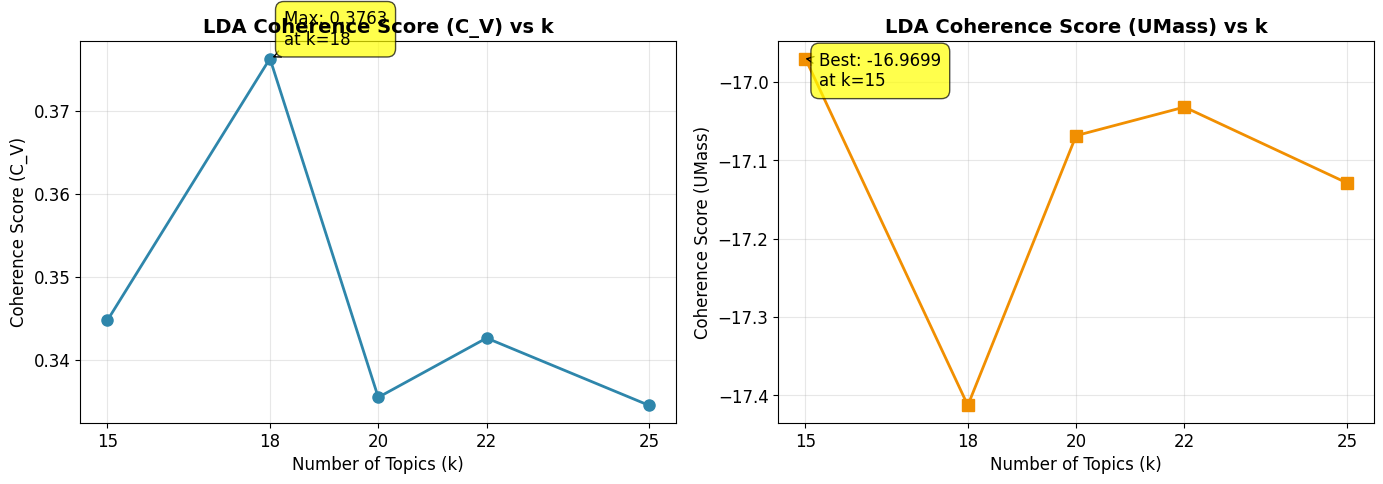

In [9]:
# ============================================================================
# CELL 9: VISUALIZE COHERENCE SCORES
# ============================================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot C_V
axes[0].plot(results_df['k'], results_df['coherence_cv'], 
             marker='o', linewidth=2, markersize=8, color='#2E86AB')
axes[0].set_xlabel('Number of Topics (k)', fontsize=12)
axes[0].set_ylabel('Coherence Score (C_V)', fontsize=12)
axes[0].set_title('LDA Coherence Score (C_V) vs k', fontsize=14, fontweight='bold')
axes[0].grid(True, alpha=0.3)
axes[0].set_xticks(K_VALUES)

# Annotate max
max_cv_idx = results_df['coherence_cv'].idxmax()
max_cv_k = results_df.loc[max_cv_idx, 'k']
max_cv_val = results_df.loc[max_cv_idx, 'coherence_cv']
axes[0].annotate(f'Max: {max_cv_val:.4f}\nat k={int(max_cv_k)}',
                 xy=(max_cv_k, max_cv_val),
                 xytext=(10, 10), textcoords='offset points',
                 bbox=dict(boxstyle='round,pad=0.5', fc='yellow', alpha=0.7),
                 arrowprops=dict(arrowstyle='->', connectionstyle='arc3,rad=0'))

# Plot UMass
axes[1].plot(results_df['k'], results_df['coherence_umass'], 
             marker='s', linewidth=2, markersize=8, color='#F18F01')
axes[1].set_xlabel('Number of Topics (k)', fontsize=12)
axes[1].set_ylabel('Coherence Score (UMass)', fontsize=12)
axes[1].set_title('LDA Coherence Score (UMass) vs k', fontsize=14, fontweight='bold')
axes[1].grid(True, alpha=0.3)
axes[1].set_xticks(K_VALUES)

# Annotate best UMass
max_umass_idx = results_df['coherence_umass'].idxmax()
max_umass_k = results_df.loc[max_umass_idx, 'k']
max_umass_val = results_df.loc[max_umass_idx, 'coherence_umass']
axes[1].annotate(f'Best: {max_umass_val:.4f}\nat k={int(max_umass_k)}',
                 xy=(max_umass_k, max_umass_val),
                 xytext=(10, -20), textcoords='offset points',
                 bbox=dict(boxstyle='round,pad=0.5', fc='yellow', alpha=0.7),
                 arrowprops=dict(arrowstyle='->', connectionstyle='arc3,rad=0'))

plt.tight_layout()

# Save plot
output_plot = os.path.join(OUTPUT_DIR, 'lda_coherence_plot_NEW.png')
plt.savefig(output_plot, dpi=150, bbox_inches='tight')
print(f"✅ Plot saved to: {output_plot}")

plt.show()

In [10]:
# ============================================================================
# CELL 10: TRAIN FINAL MODEL VỚI k TỐI ƯU
# ============================================================================

optimal_k = int(results_df.loc[results_df['coherence_cv'].idxmax(), 'k'])
print(f"🎯 Training final model with k={optimal_k}...")

final_lda = LdaMulticore(
    corpus=corpus,
    id2word=dictionary,
    num_topics=optimal_k,
    iterations=50,
    passes=10,
    workers=2,
    random_state=42
)

# Save model
model_path = os.path.join(OUTPUT_DIR, 'lda_model_final_NEW')
final_lda.save(model_path)
print(f"✅ Model saved to: {model_path}")

# Save dictionary
dict_path = os.path.join(OUTPUT_DIR, 'lda_dictionary_NEW')
dictionary.save(dict_path)
print(f"✅ Dictionary saved to: {dict_path}")

2026-04-04 10:27:37,052 : INFO : using symmetric alpha at 0.05555555555555555
2026-04-04 10:27:37,053 : INFO : using symmetric eta at 0.05555555555555555
2026-04-04 10:27:37,054 : INFO : using serial LDA version on this node
2026-04-04 10:27:37,055 : INFO : running online LDA training, 18 topics, 10 passes over the supplied corpus of 129 documents, updating every 4000 documents, evaluating every ~129 documents, iterating 50x with a convergence threshold of 0.001000
2026-04-04 10:27:37,055 : INFO : training LDA model using 2 processes
2026-04-04 10:27:37,181 : INFO : PROGRESS: pass 0, dispatched chunk #0 = documents up to #129/129, outstanding queue size 1


🎯 Training final model with k=18...


2026-04-04 10:27:38,262 : INFO : topic #16 (0.056): 0.045*"cấu_hình" + 0.038*"triệu" + 0.032*"anh_em" + 0.032*"code" + 0.032*"nhờ_vả" + 0.032*"tư_vấn" + 0.032*"giá" + 0.032*"aaa" + 0.032*"góc" + 0.032*"đầu"
2026-04-04 10:27:38,262 : INFO : topic #13 (0.056): 0.075*"mua" + 0.030*"card" + 0.030*"lò" + 0.030*"nóng_như" + 0.030*"chia_sẻ" + 0.030*"họa" + 0.030*"gạch" + 0.030*"mở_mang" + 0.030*"tâm" + 0.030*"trâu"
2026-04-04 10:27:38,262 : INFO : topic #4 (0.056): 0.066*"dạo" + 0.040*"đói" + 0.040*"it" + 0.040*"sinh_viên" + 0.040*"ghê" + 0.040*"code" + 0.040*"liệu" + 0.040*"trường" + 0.032*"rẻ" + 0.027*"apple"
2026-04-04 10:27:38,262 : INFO : topic #9 (0.056): 0.117*"giá" + 0.040*"rẻ" + 0.040*"dự_kiến" + 0.040*"triệu" + 0.040*"niêm_yết" + 0.040*"thế_hệ" + 0.040*"ngang" + 0.020*"ghim" + 0.020*"trâu" + 0.020*"bàn_phím"
2026-04-04 10:27:38,272 : INFO : topic #8 (0.056): 0.094*"rẻ" + 0.047*"ngon_bổ" + 0.047*"đồn" + 0.047*"giá" + 0.047*"đánh_giá" + 0.047*"chi_tiết" + 0.047*"tàu" + 0.047*"thực_sự"

✅ Model saved to: ../output\lda_model_final_NEW
✅ Dictionary saved to: ../output\lda_dictionary_NEW


In [11]:
# ============================================================================
# CELL 11: HIỂN THỊ TOP WORDS CHO MỖI TOPIC
# ============================================================================

print(f"\n{'='*80}")
print(f"TOP 10 WORDS FOR EACH TOPIC (k={optimal_k})")
print(f"{'='*80}\n")

topic_words_list = []
for idx, topic in final_lda.print_topics(num_topics=optimal_k, num_words=10):
    print(f"Topic {idx+1}:")
    # Parse topic string
    words = re.findall(r'"([^"]+)"', topic)
    print(f"  {', '.join(words)}")
    print()
    
    topic_words_list.append({
        'topic_id': idx,
        'topic_label': f'Topic {idx+1}',
        'top_words': ', '.join(words)
    })

# Save to CSV
topics_csv = os.path.join(OUTPUT_DIR, 'lda_topics_final_NEW.csv')
pd.DataFrame(topic_words_list).to_csv(topics_csv, index=False)
print(f"✅ Topics saved to: {topics_csv}")

2026-04-04 10:27:51,518 : INFO : topic #0 (0.056): 0.086*"anh_em" + 0.086*"tiền" + 0.086*"tỉnh" + 0.086*"kẻo" + 0.086*"gian_thương" + 0.086*"ác" + 0.086*"lừa_đảo" + 0.086*"bọn" + 0.086*"dạo" + 0.086*"oan"
2026-04-04 10:27:51,518 : INFO : topic #1 (0.056): 0.011*"quyết_định" + 0.011*"đợi" + 0.011*"thời_gian" + 0.011*"thử_thách" + 0.011*"cuối_cùng" + 0.011*"hẵng" + 0.011*"nhiệt_độ" + 0.011*"độc_lập" + 0.011*"tình_cảm" + 0.009*"ram"
2026-04-04 10:27:51,518 : INFO : topic #2 (0.056): 0.105*"cuối_cùng" + 0.105*"độc_lập" + 0.105*"tình_cảm" + 0.105*"thử_thách" + 0.105*"thời_gian" + 0.105*"quyết_định" + 0.105*"nhiệt_độ" + 0.105*"hẵng" + 0.105*"đợi" + 0.001*"cấu_hình"
2026-04-04 10:27:51,521 : INFO : topic #3 (0.056): 0.008*"anh_em" + 0.008*"chia_sẻ" + 0.008*"mở_mang" + 0.008*"thanks_thím" + 0.008*"tâm" + 0.008*"tầm_mắt" + 0.008*"đánh_giá" + 0.008*"cuối_cùng" + 0.008*"hẵng" + 0.008*"nhiệt_độ"
2026-04-04 10:27:51,521 : INFO : topic #4 (0.056): 0.114*"dạo" + 0.114*"it" + 0.114*"ghê" + 0.114*"sinh


TOP 10 WORDS FOR EACH TOPIC (k=18)

Topic 1:
  anh_em, tiền, tỉnh, kẻo, gian_thương, ác, lừa_đảo, bọn, dạo, oan

Topic 2:
  quyết_định, đợi, thời_gian, thử_thách, cuối_cùng, hẵng, nhiệt_độ, độc_lập, tình_cảm, ram

Topic 3:
  cuối_cùng, độc_lập, tình_cảm, thử_thách, thời_gian, quyết_định, nhiệt_độ, hẵng, đợi, cấu_hình

Topic 4:
  anh_em, chia_sẻ, mở_mang, thanks_thím, tâm, tầm_mắt, đánh_giá, cuối_cùng, hẵng, nhiệt_độ

Topic 5:
  dạo, it, ghê, sinh_viên, trường, đói, liệu, code, rẻ, apple

Topic 6:
  đi, giá, bình_thường, xui_xẻo, hãng, hướng, thông_tin, nóng_như, lò, cũ_rích

Topic 7:
  giá, món, chúc_mừng, như_vậy, hời, cấu_hình, vấn_đề, họa, đánh_giá, nhu_cầu

Topic 8:
  viết, ghim, tụt, xài, bụng, ưng, sóng_khỏe, nói_chung, trâu, máy

Topic 9:
  rẻ, đánh_giá, tàu, giá, thực_sự, chi_tiết, đồn, ngon_bổ, bàn_phím, thiết_kế

Topic 10:
  giá, rẻ, niêm_yết, triệu, dự_kiến, thế_hệ, ngang, trâu, ghim, bàn_phím

Topic 11:
  bình_thường, thông_tin, hãng, đi, xui_xẻo, hướng, đánh_giá, sử_dụng,

In [12]:
# ============================================================================
# CELL 12: SUMMARY
# ============================================================================

print(f"\n{'='*80}")
print("📋 LDA EVALUATION SUMMARY")
print(f"{'='*80}")
print(f"✅ Documents processed: {len(documents)}")
print(f"✅ Vocabulary size: {len(dictionary)}")
print(f"✅ K values tested: {K_VALUES}")
print(f"✅ Optimal k: {optimal_k}")
print(f"✅ Best Coherence C_V: {results_df['coherence_cv'].max():.4f}")
print(f"✅ Best Coherence UMass: {results_df['coherence_umass'].max():.4f}")
print(f"\n📁 Output files:")
print(f"   - output/lda_coherence_results_NEW.csv")
print(f"   - output/lda_coherence_plot_NEW.png")
print(f"   - output/lda_model_final_NEW/")
print(f"   - output/lda_dictionary_NEW")
print(f"   - output/lda_topics_final_NEW.csv")
print(f"{'='*80}")
print("✅ Task 2.2 completed successfully!")
print(f"{'='*80}\n")


📋 LDA EVALUATION SUMMARY
✅ Documents processed: 129
✅ Vocabulary size: 119
✅ K values tested: [15, 18, 20, 22, 25]
✅ Optimal k: 18
✅ Best Coherence C_V: 0.3763
✅ Best Coherence UMass: -16.9699

📁 Output files:
   - output/lda_coherence_results_NEW.csv
   - output/lda_coherence_plot_NEW.png
   - output/lda_model_final_NEW/
   - output/lda_dictionary_NEW
   - output/lda_topics_final_NEW.csv
✅ Task 2.2 completed successfully!

